#Εξόρυξη Δεδομένων Άσκηση 3 Ερώτηση 2

ΟΜΑΔΑ: Αριστείδης Νικολακόπουλος (cs5308), Χρήστος Γιαμαλής (ma12834)

USING 2 FREE PASSES

Question2 Code:

Movie-User Matrix Shape: (2245, 671)


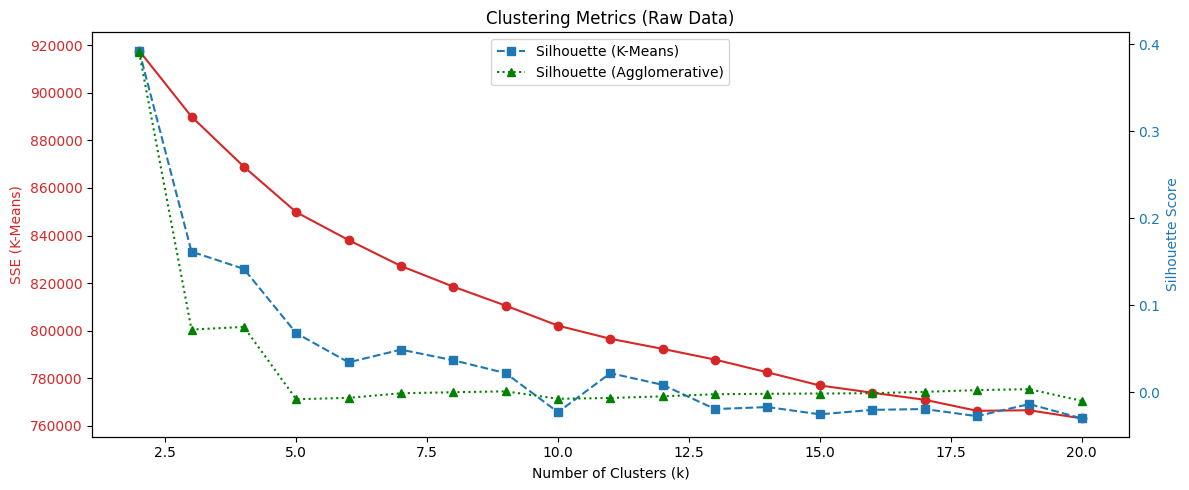

Cluster 0: Top 3 Genres by Lift - ['War', 'History', 'Drama']
Cluster 1: Top 3 Genres by Lift - ['Action', 'Thriller', 'Mystery']
Cluster 2: Top 3 Genres by Lift - ['Horror', 'Music', 'Western']
Cluster 3: Top 3 Genres by Lift - ['Fantasy', 'Science Fiction', 'Adventure']
Cluster 4: Top 3 Genres by Lift - ['Animation', 'Science Fiction', 'Adventure']


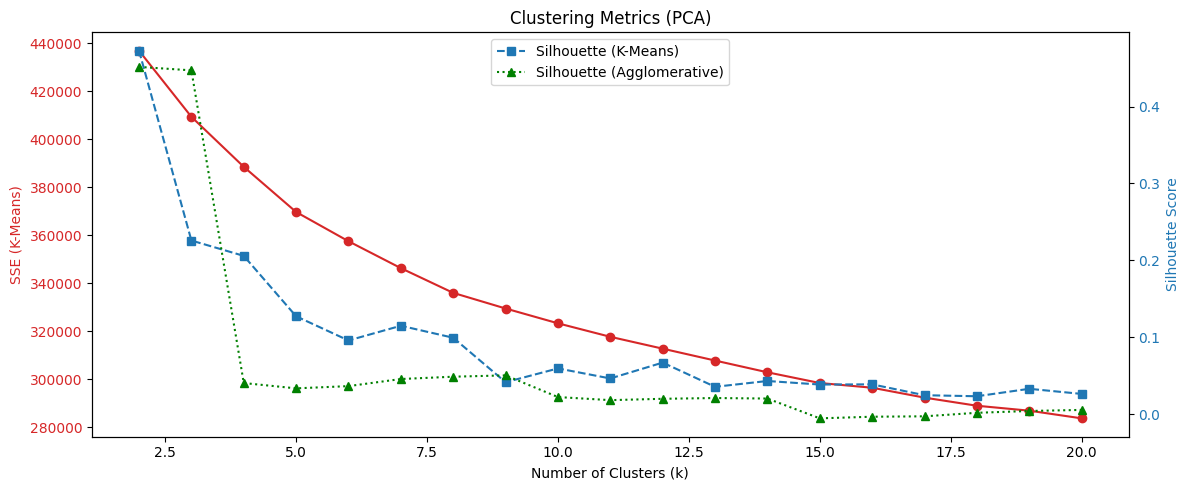

Cluster 0: Top 3 Genres by Lift - ['Horror', 'Music', 'Western']
Cluster 1: Top 3 Genres by Lift - ['War', 'History', 'Drama']
Cluster 2: Top 3 Genres by Lift - ['Action', 'Mystery', 'Thriller']
Cluster 3: Top 3 Genres by Lift - ['Fantasy', 'Science Fiction', 'Adventure']
Cluster 4: Top 3 Genres by Lift - ['Animation', 'Science Fiction', 'Adventure']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import warnings
from ast import literal_eval
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, precision_score, recall_score, accuracy_score, make_scorer, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_validate, train_test_split, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import pairwise_distances
import gensim.downloader as api
from gensim.utils import simple_preprocess
from gensim.models import Word2Vec
warnings.filterwarnings("ignore")

RATINGS_PATH = 'ratings_small.csv'
LINKS_PATH = 'links_small.csv'
METADATA_PATH = 'movies_metadata.csv'


ratings = pd.read_csv(RATINGS_PATH)
links = pd.read_csv(LINKS_PATH)
metadata = pd.read_csv(METADATA_PATH, low_memory=False)

movie_counts = ratings['movieId'].value_counts()
valid_movies = movie_counts[movie_counts >= 10].index
ratings_filtered = ratings[ratings['movieId'].isin(valid_movies)]

movie_user_matrix = ratings_filtered.pivot(index='movieId', columns='userId', values='rating').fillna(0)
print(f"Movie-User Matrix Shape: {movie_user_matrix.shape}")

def evaluate_clustering(X, k_range, title_suffix=""):
    sse = []
    sil_kmeans = []
    sil_agg = []


    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km_labels = km.fit_predict(X)
        sse.append(km.inertia_)
        if k > 1:
            sil_kmeans.append(silhouette_score(X, km_labels))
        else:
            sil_kmeans.append(0)

        agg = AgglomerativeClustering(n_clusters=k)
        agg_labels = agg.fit_predict(X)
        if k > 1:
            sil_agg.append(silhouette_score(X, agg_labels))
        else:
            sil_agg.append(0)

    fig, ax1 = plt.subplots(figsize=(12, 5))

    color = 'tab:red'
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('SSE (K-Means)', color=color)
    ax1.plot(k_range, sse, marker='o', color=color, label='SSE (K-Means)')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Silhouette Score', color=color)
    ax2.plot(k_range, sil_kmeans, marker='s', linestyle='--', color=color, label='Silhouette (K-Means)')
    ax2.plot(k_range, sil_agg, marker='^', linestyle=':', color='green', label='Silhouette (Agglomerative)')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Clustering Metrics {title_suffix}')
    fig.tight_layout()
    plt.legend(loc='upper center')
    plt.show()

evaluate_clustering(movie_user_matrix, range(2, 21), "(Raw Data)")

metadata['id'] = pd.to_numeric(metadata['id'], errors='coerce')
metadata = metadata.dropna(subset=['id'])
metadata['id'] = metadata['id'].astype(int)
links = links.dropna(subset=['tmdbId'])
links['tmdbId'] = links['tmdbId'].astype(int)

movie_ids = pd.DataFrame(movie_user_matrix.index, columns=['movieId'])
merged = movie_ids.merge(links, on='movieId', how='left')
merged = merged.merge(metadata[['id', 'genres']], left_on='tmdbId', right_on='id', how='left')

def extract_genres(x):
    try:
        return [g['name'] for g in literal_eval(str(x))]
    except:
        return []

merged['genres_list'] = merged['genres'].apply(extract_genres)
all_genres = [g for sublist in merged['genres_list'] for g in sublist]
global_freq = pd.Series(all_genres).value_counts(normalize=True)

def analyze_clusters(X, k, global_freq, merged_df):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)


    for i in range(k):
        cluster_indices = np.where(labels == i)[0]
        cluster_genres = []
        for idx in cluster_indices:
            cluster_genres.extend(merged_df.iloc[idx]['genres_list'])

        if not cluster_genres:
            continue

        cluster_freq = pd.Series(cluster_genres).value_counts(normalize=True)

        lift = cluster_freq / global_freq
        lift = lift.dropna().sort_values(ascending=False)

        print(f"Cluster {i}: Top 3 Genres by Lift - {lift.head(3).index.tolist()}")

analyze_clusters(movie_user_matrix, 5, global_freq, merged)


pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(movie_user_matrix)

evaluate_clustering(X_pca, range(2, 21), "(PCA)")
analyze_clusters(X_pca, 5, global_freq, merged)

#Step 1

#Results



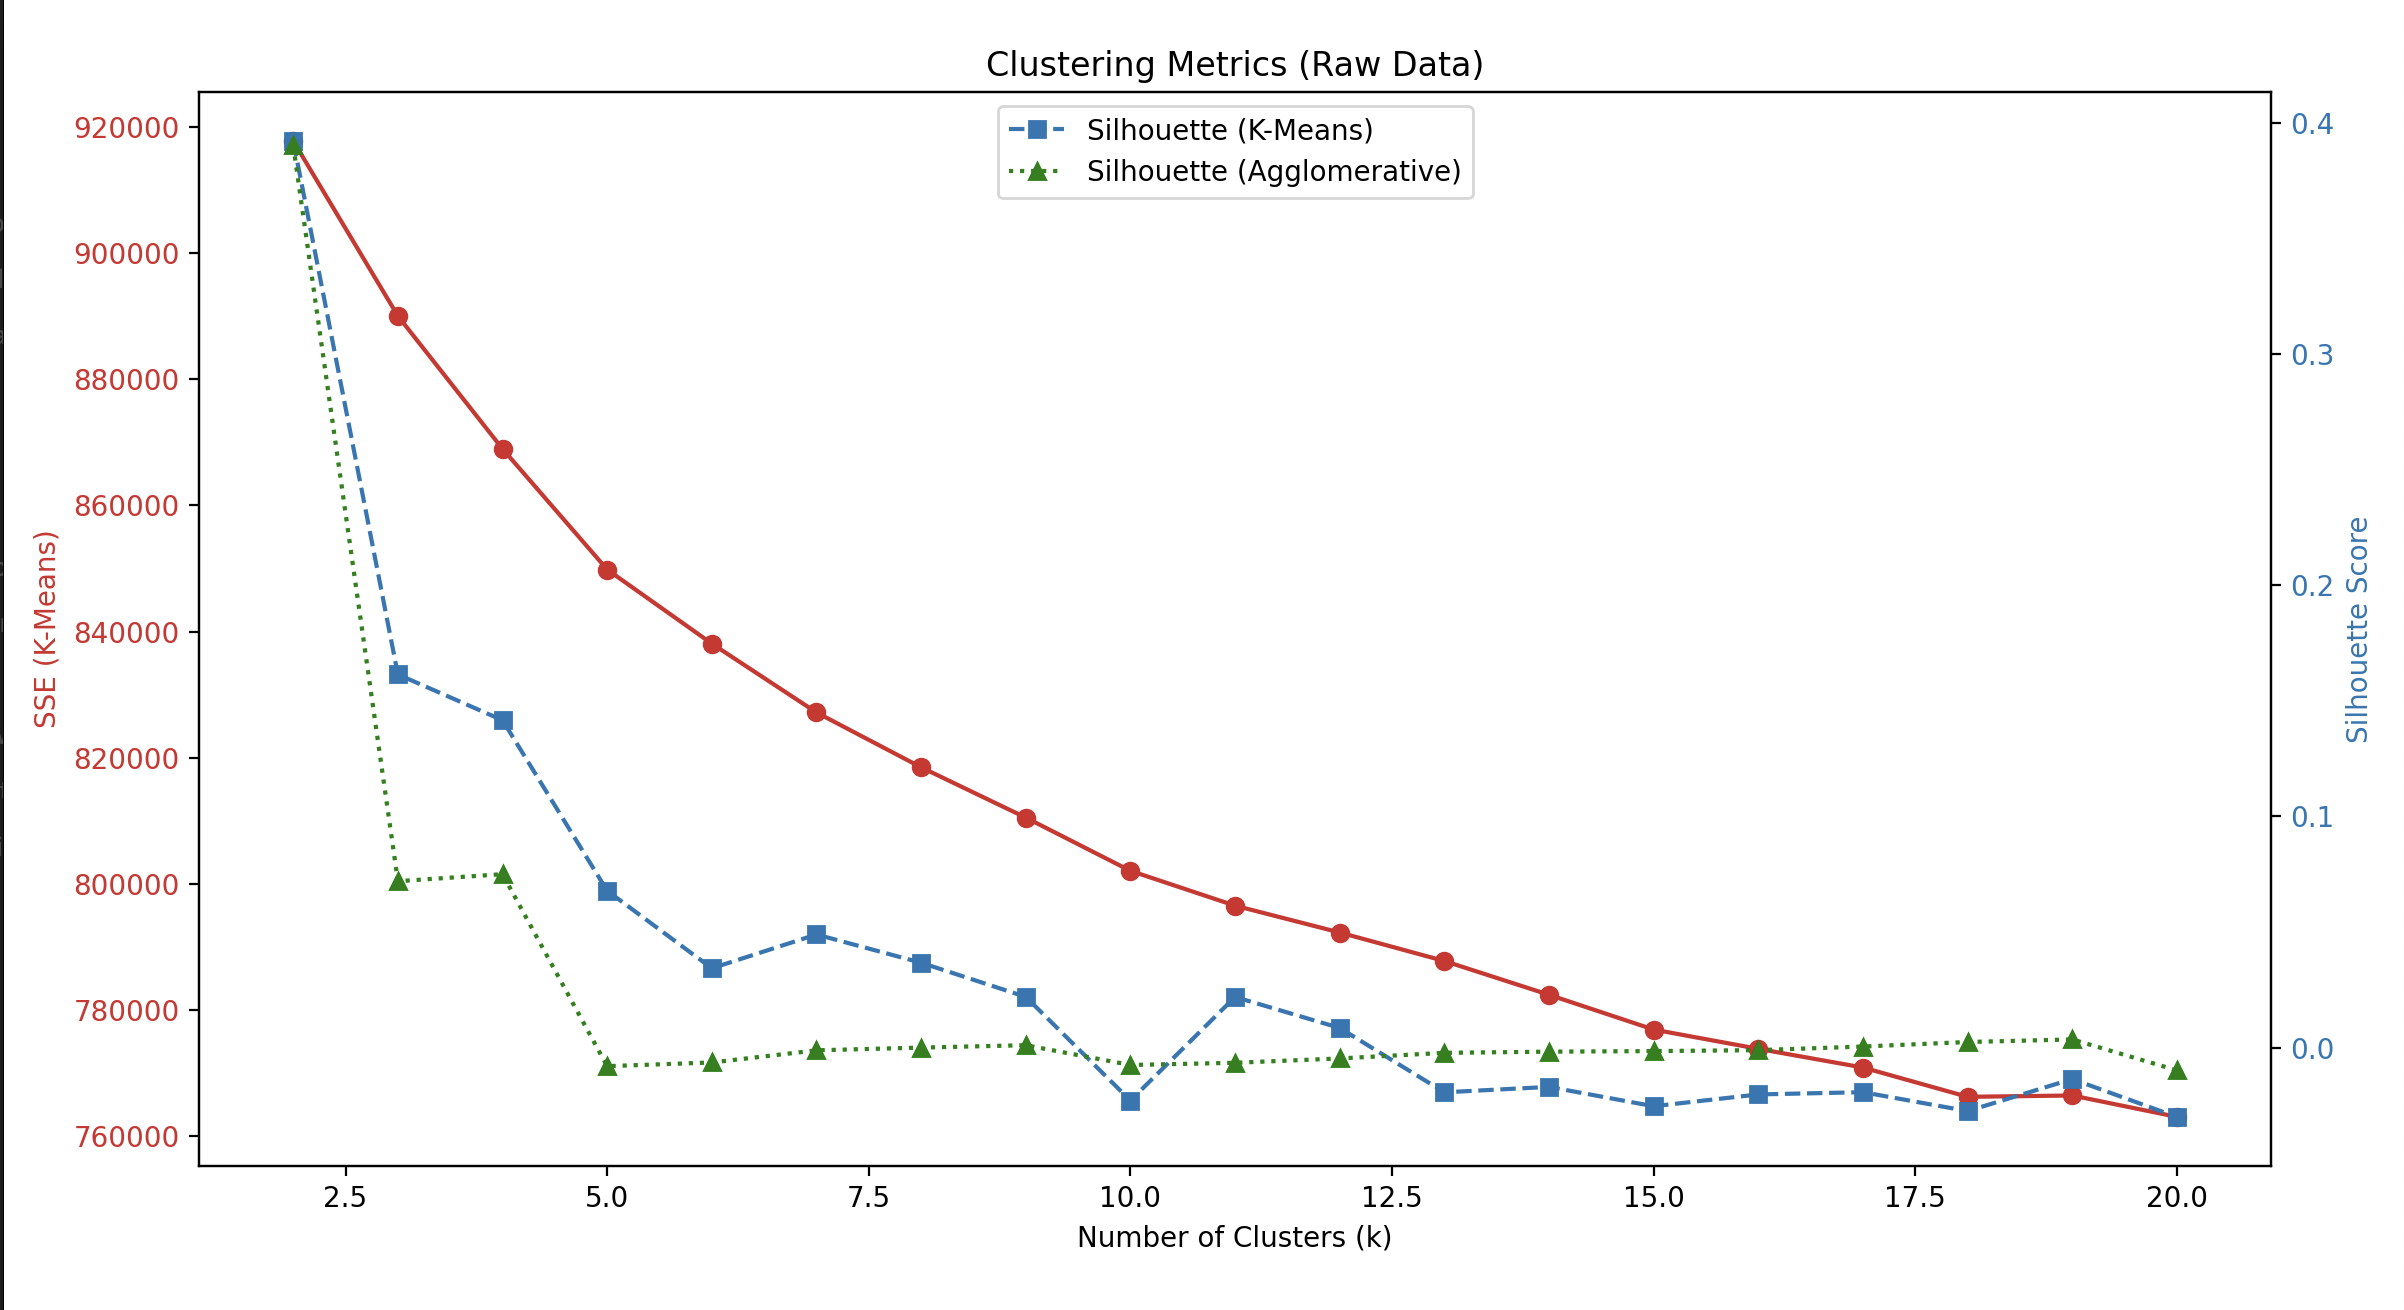


#Επιλογή Καλύτερου κ και αιτολόγιση
Για την επιλογή του αριθμού των clusters εφαρμόστηκε ο αλγόριθμος k-means για τιμές k από 2 έως 20. Από το γράφημα παρατηρείται ότι το Sum of Squares Error (SSE) παρουσιάζει έντονη μείωση έως το k=5, ενώ για μεγαλύτερες τιμές η βελτίωση είναι περιορισμένη, γεγονός που υποδεικνύει την ύπαρξη elbow στο k=5. Παράλληλα, ο silhouette coefficient του k-means για το k=5 διατηρεί θετική τιμή, υποδεικνύοντας ικανοποιητική διαχωρισιμότητα των clusters. Επομένως, το k=5 επιλέγεται ως ο βέλτιστος αριθμός clusters.
Στη συνέχεια, εφαρμόστηκε ο agglomerative clustering αλγόριθμος με τον ίδιο αριθμό clusters (k=5). Τα αποτελέσματα παρουσιάζουν χαμηλότερες τιμές silhouette σε σύγκριση με τον k-means, γεγονός που υποδηλώνει ότι για τα συγκεκριμένα δεδομένα ο k-means επιτυγχάνει καλύτερη διαχωρισιμότητα των clusters.

#Step 2
#Χρήση του lift για εύρεση των 3 gernes per cluster με το μεγαλύτερο lift

#Results:

Cluster 0: Top 3 Genres by Lift - ['War', 'History', 'Drama']

Cluster 1: Top 3 Genres by Lift - ['Action', 'Thriller', 'Mystery']

Cluster 2: Top 3 Genres by Lift - ['Horror', 'Music', 'Western']

Cluster 3: Top 3 Genres by Lift - ['Fantasy', 'Science Fiction', 'Adventure']

Cluster 4: Top 3 Genres by Lift - ['Animation', 'Science Fiction', 'Adventure']


#Εικασία του τι αντιπροσωπεύει κάθει cluster και αξιολόγιση ομοδοποίησης

Cluster 0: Ιστορικά Πολεμικά Δράματα, ταινίες με σοβαρό ύφος και ρεαλιστικό τόνο

Cluster 1: Ταινίες Δράσης με αγωνία και μυστήριο, ταινίες με γρήγορο ρυθμό, ένταση και σασπένς

Cluster 2: Εξειδικευμένα Κινηματογραφικά Είδη, είδη που δεν ειναι mainstream και έχουν το κοινό-"πυρήνα" τους

Cluster 3: Επικές και Φανταστικές Περιπέτειες, ταινίες σε φανταστικούς κόσμους με έμφαση στην περιπέτεια

Cluster 4: Ταινίες animation σε φανταστικούς και έμφαση την περιπέτεια

Αξιολόγιση:
Τα clusters παρουσιάζουν σαφή θεματική συνοχή, καθώς τα genres με το μεγαλύτερο lift είναι εννοιολογικά συγγενή. Αυτό υποδηλώνει ότι η ομαδοποίηση κατάφερε να διαχωρίσει τις ταινίες σε νοηματικές κατηγορίες με βάση τα πρότυπα βαθμολόγησης των χρηστών.


#Step 3

#Results
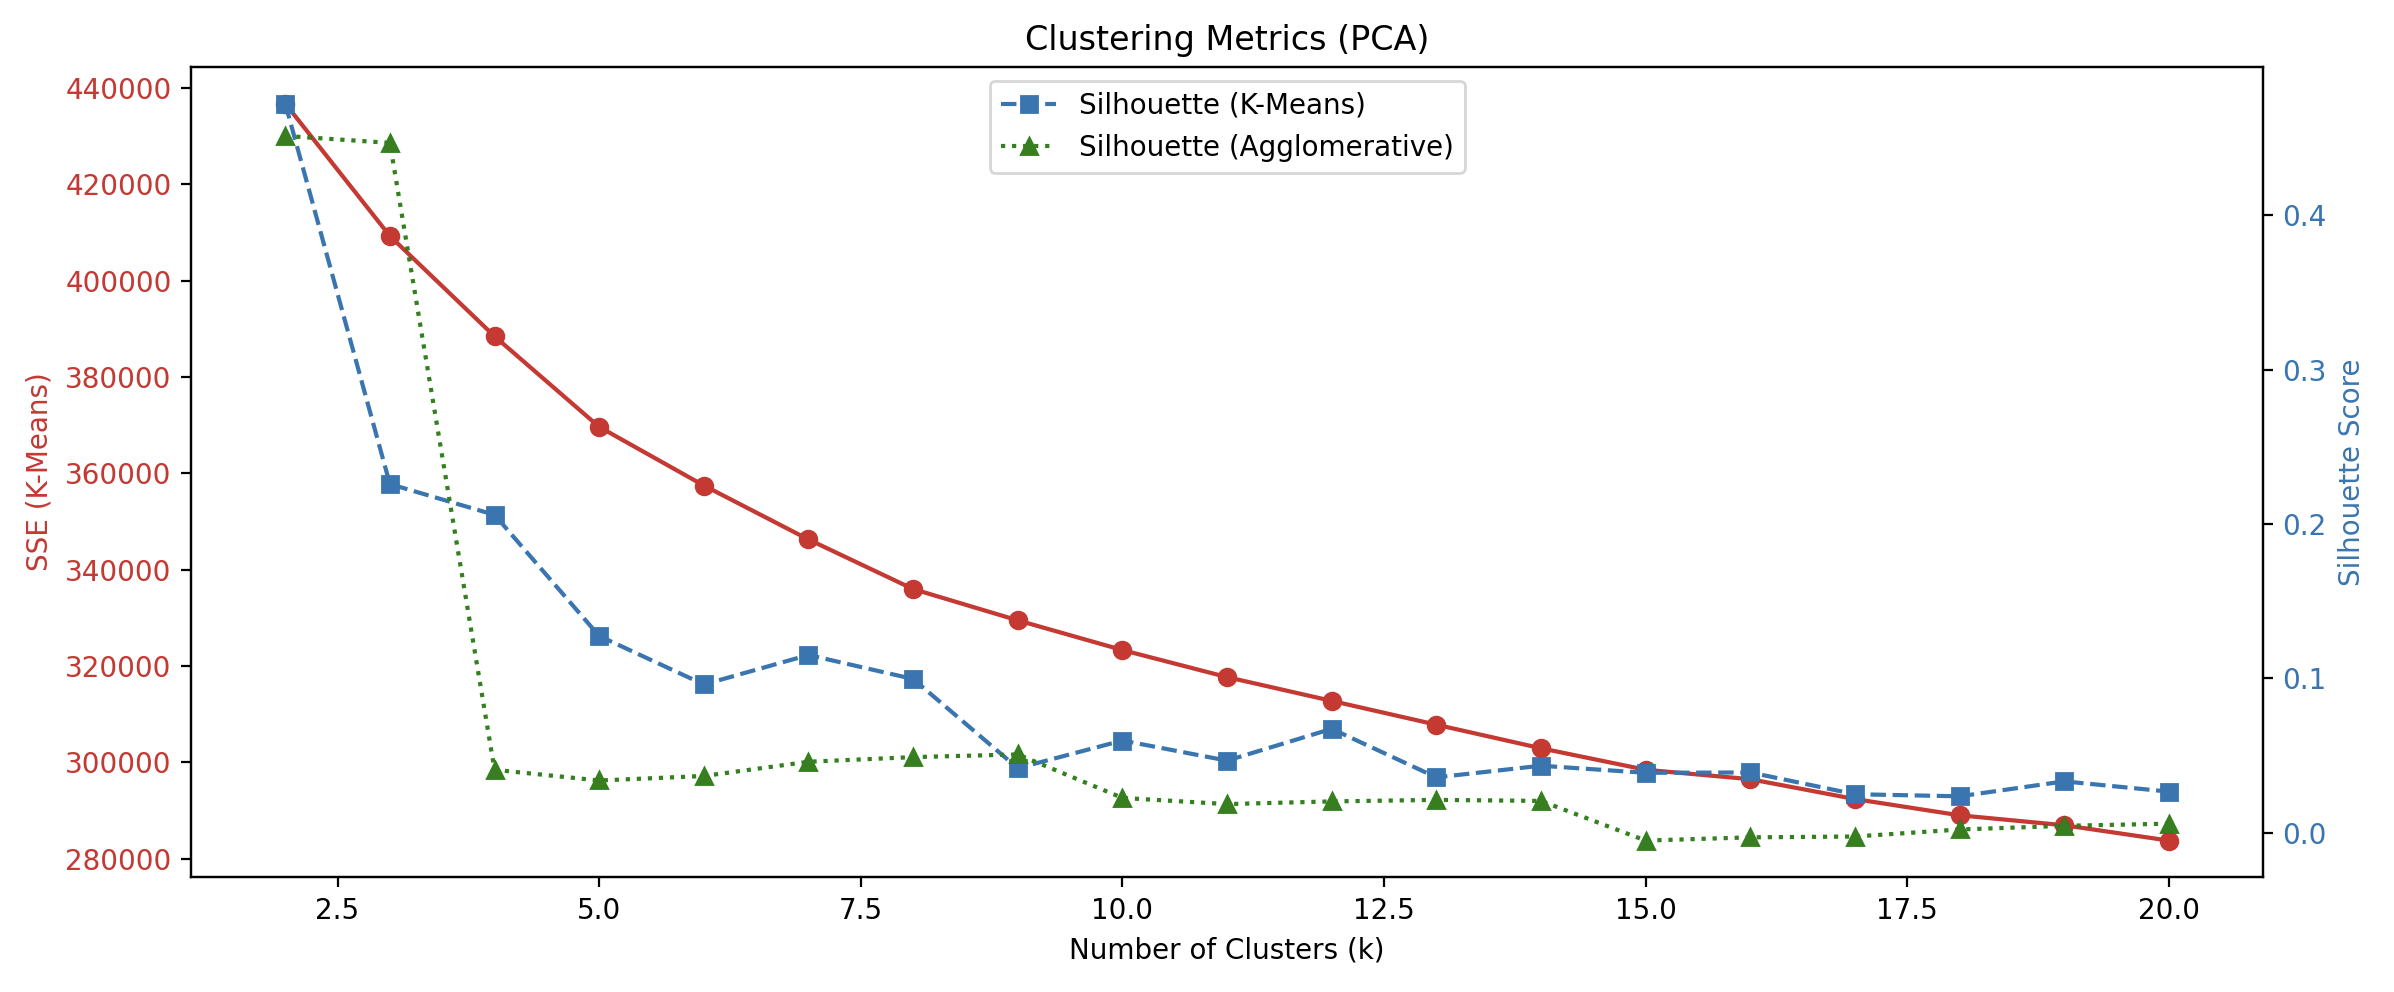

#Διαφορές Στα Αποτελέσματα

1. Πολύ μικρότερες τιμές SSE
(280.000 – 440.000 αντί για 760.000 -920.000)

2. Πιο «ομαλή» συμπεριφορά του k-means

3. Αλλαγή συμπεριφοράς του agglomerative
(Η απότομη μείωση συμβαίνει απο το 3ο cluster και μετά)